## 🚁 MASA: Exploratory Data Analysis (EDA)

# Business Context

**Objective:** Diagnostic of the current medical supply chain in Ghana. 

This notebook analyzes the accessibility of health facilities and evaluates the performance of the existing drone network (Zipline) to justify the optimization of new hubs.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap, Fullscreen
from geopy.distance import geodesic
import warnings
warnings.filterwarnings('ignore')

# Loading datasets
df_health = pd.read_csv('../data/ghana_health_facilities.csv')
df_villages = pd.read_csv('../data/ghana_villages_clean.csv')

# Keeping defensive copies
df1 = df_health.copy()
df2 = df_villages.copy()

## 1. Data Inspection & Initial Cleaning


Before starting the analysis, we check the integrity of our datasets and remove unnecessary columns or duplicates to ensure high-quality insights.

In [40]:
print("--- Health Facilities Info ---")
df_health.info()
print("\n--- Villages Dataset Info ---")
df_villages.info()
display(df_villages.describe())

--- Health Facilities Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2463 entries, 0 to 2462
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Facility_Name     2463 non-null   object 
 1   Facility_Type     2463 non-null   object 
 2   Latitude          2463 non-null   float64
 3   Longitude         2463 non-null   float64
 4   Data_Sources      2463 non-null   object 
 5   Confidence_Score  2463 non-null   float64
 6   OSM_ID            2463 non-null   int64  
 7   Operator          192 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 154.1+ KB

--- Villages Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8905 entries, 0 to 8904
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Village                       8905 non-null   object 
 1   Latitude 

,Latitude,Longitude,Elevation_m,Population,Nearest_Facility_Latitude,Nearest_Facility_Longitude,Distance_Nearest_Facility_km,Nearest_Facility_Confidence
count,8905.000000,8905.000000,8905.000000,8.905000e+03,8905.000000,8905.000000,8905.000000,8905.000000
mean,7.058856,-1.113893,177.841437,6.210639e+03,7.054646,-1.113331,9.261330,0.667898
std,1.527181,0.952292,97.618012,4.634090e+04,1.530712,0.957432,8.853003,0.149349
min,4.739811,-3.246019,-2.000000,5.000000e+00,4.866764,-3.182800,0.010000,0.130000
25%,5.923368,-1.832259,110.000000,4.390000e+02,5.868827,-1.842307,2.920000,0.530000
50%,6.607157,-1.032793,171.000000,9.070000e+02,6.613570,-0.993307,7.070000,0.630000
75%,7.671473,-0.336698,241.000000,2.627000e+03,7.738077,-0.343671,12.580000,0.810000
max,11.148113,1.196421,719.000000,2.388000e+06,11.115618,1.188693,64.710000,0.950000


In [41]:
# Dropping almost empty columns
if 'Operator' in df_health.columns:
    df_health = df_health.drop(columns=['Operator'])

# Check for duplicates
print(f"Duplicates in Health Facilities: {df_health.duplicated().sum()}")
print(f"Duplicates in Village Dataset: {df_villages.duplicated().sum()}")



Duplicates in Health Facilities: 0
Duplicates in Village Dataset: 0


In [42]:
# Categorization of Health Facilities
def categorize_facility(ftype):
    ftype = str(ftype).lower()
    if 'chps' in ftype: return 'CHPS'
    elif 'clinic' in ftype: return 'Clinic'
    elif 'hospital' in ftype: return 'Hospital'
    else: return 'Other'

df_health['Category'] = df_health['Facility_Type'].apply(categorize_facility)

## 2. Spatial Distribution Analysis

We plot all geographical points to verify if they match the borders of Ghana and to observe the density of infrastructures.

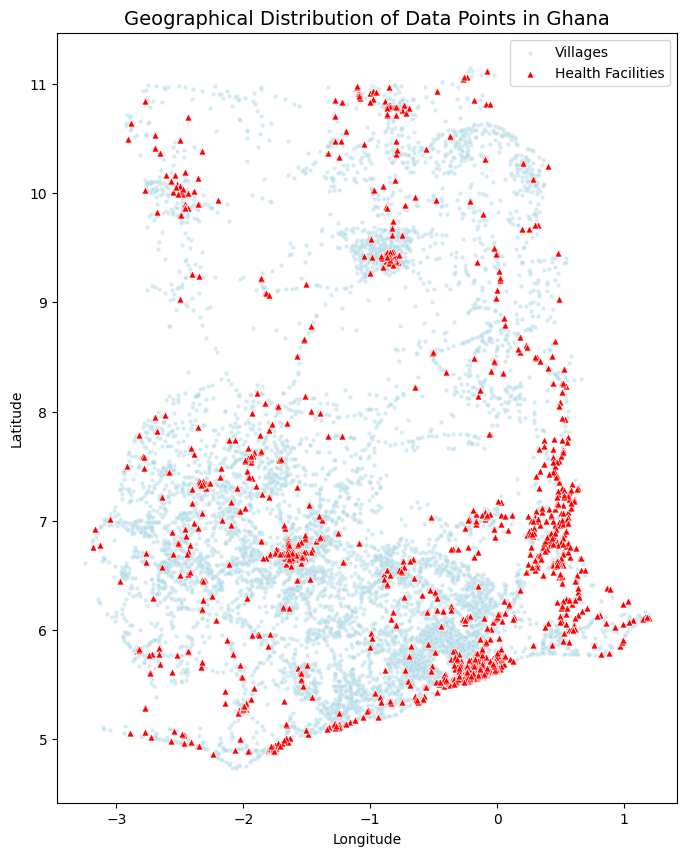

In [43]:
plt.figure(figsize=(8, 10))
sns.scatterplot(data=df_villages, x='Longitude', y='Latitude', color='lightblue', s=10, alpha=0.5, label='Villages')
sns.scatterplot(data=df_health, x='Longitude', y='Latitude', color='red', s=25, marker='^', label='Health Facilities')
plt.title('Geographical Distribution of Data Points in Ghana', fontsize=14)
plt.legend()
plt.show()


Conclusion: The data points perfectly align with Ghana's geography.
No outliers were detected in the ocean or neighboring countries. We notice a high concentration of health facilities in the South, while the North and Central regions show vast populated areas with very few medical centers.

## 3. Analysis of Medical Deserts

We evaluate the "Blind Spots" by analyzing the distance between villages and the nearest medical centers. We use a **15km threshold** as the limit for emergency accessibility.
Cell 9: Histogram & Boxplot (Code)

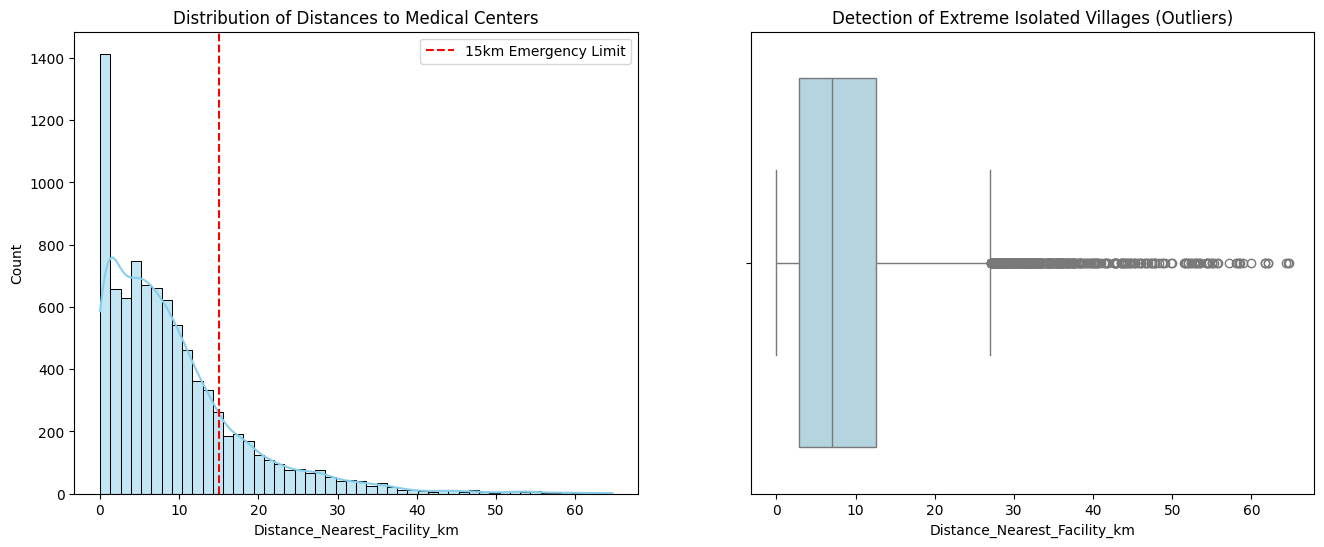

Percentage of isolated villages (>15km): 18.28%


In [44]:
# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(df_villages['Distance_Nearest_Facility_km'], bins=50, kde=True, color='skyblue', ax=axes[0])
axes[0].axvline(15, color='red', linestyle='--', label='15km Emergency Limit')
axes[0].set_title('Distribution of Distances to Medical Centers')
axes[0].legend()

# Boxplot
sns.boxplot(x=df_villages['Distance_Nearest_Facility_km'], color='lightblue', ax=axes[1])
axes[1].set_title('Detection of Extreme Isolated Villages (Outliers)')

plt.show()

# Calculate stats
isolated_perc = (df_villages[df_villages['Distance_Nearest_Facility_km'] > 15].shape[0] / len(df_villages)) * 100
print(f"Percentage of isolated villages (>15km): {isolated_perc:.2f}%")

**Conclusion:** Over **18% of villages** are located more than 15km away from a medical center. In rural areas, this distance is a critical barrier for emergency care, justifying the need for rapid drone delivery.

## 4. Diagnostic of the Current Zipline Network

We evaluate how the existing network (6 Zipline hubs) covers the current health facilities and population.

In [46]:
# Define Hubs
ZIPLINE_HUBS = [
    {"name": "Omenako (GH1)", "lat": 6.2027, "lon": -0.4462},
    {"name": "Mpanya (GH2)", "lat": 7.0545, "lon": -1.3855},
    {"name": "Vobsi (GH3)", "lat": 10.3470, "lon": -0.8035},
    {"name": "Sefwi Wiawso (GH4)", "lat": 6.1820, "lon": -2.4845},
    {"name": "Anum (GH5)", "lat": 6.4885, "lon": 0.1625},
    {"name": "Kete Krachi (GH6)", "lat": 7.7981, "lon": -0.0125}
]

In [48]:
# Distance Calculation to nearest Zipline hub
def get_min_dist(row, hubs):
    return min([geodesic((row['Latitude'], row['Longitude']), (h['lat'], h['lon'])).km for h in hubs])

df_health['Dist_Zipline_km'] = df_health.apply(get_min_dist, axis=1, hubs=ZIPLINE_HUBS)

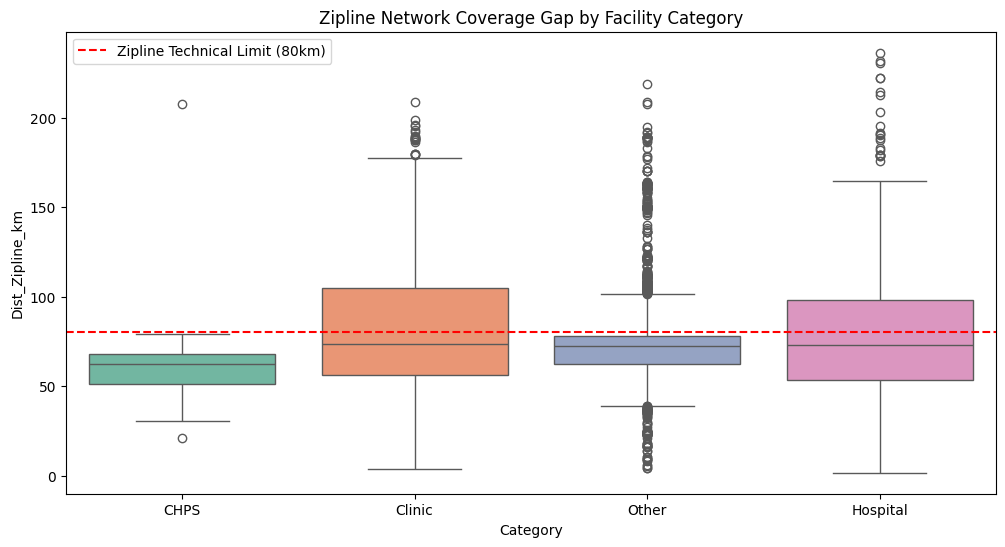

In [49]:
# Boxplot by Category
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_health, x='Category', y='Dist_Zipline_km', palette='Set2')
plt.axhline(80, color='red', linestyle='--', label='Zipline Technical Limit (80km)')
plt.title('Zipline Network Coverage Gap by Facility Category')
plt.legend()
plt.show()

Conclusion: We notify that almost the half of clinics and hospitals of Ghana are not covered by Zipline network.

## 5. Visual Diagnostic Dashboard


The final interactive map overlays population density with the current network's reach to identify uncovered high-density zones.

In [50]:
# Calculate Rates
total_facilities = len(df_health)
covered_facilities = len(df_health[df_health['Dist_Zipline_km'] <= 80])
facility_coverage_rate = (covered_facilities / total_facilities) * 100

def is_village_covered(row, hubs):
    return any(geodesic((row['Latitude'], row['Longitude']), (h['lat'], h['lon'])).km <= 80 for h in hubs)

df_villages['is_covered'] = df_villages.apply(is_village_covered, axis=1, hubs=ZIPLINE_HUBS)
pop_coverage_rate = (df_villages[df_villages['is_covered']]['Population'].sum() / df_villages['Population'].sum()) * 100

# Map & Legend code (the one we just did with the HTML box)
# [Insère ici le code Folium avec la légende HTML de mon message précédent]

In [51]:
# Map Initialization
m = folium.Map(location=[7.9465, -1.0232], zoom_start=7, tiles='CartoDB positron')

# Add Layers (Heatmap & Facilities)
heat_data = [[r['Latitude'], r['Longitude'], r['Population']] for _, r in df_villages.iterrows()]
HeatMap(heat_data, radius=15, blur=20, min_opacity=0.3).add_to(m)

for hub in ZIPLINE_HUBS:
    folium.Marker([hub['lat'], hub['lon']], icon=folium.Icon(color='black', icon='plane', prefix='fa')).add_to(m)
    folium.Circle([hub['lat'], hub['lon']], radius=80000, color='black', fill=True, fill_opacity=0.05, weight=1, dash_array='5, 5').add_to(m)

category_colors = {'Hospital': 'red', 'Clinic': '#3186cc', 'CHPS': 'green', 'Other': 'grey'}
for _, row in df_health.iterrows():
    folium.CircleMarker([row['Latitude'], row['Longitude']], radius=3, color=category_colors.get(row['Category'], 'grey'), fill=True, fill_opacity=0.7).add_to(m)

# DASHBOARD LEGEND (HTML/CSS)
legend_html = f"""
     <div style="position: fixed; 
                 bottom: 50px; right: 20px; width: 280px; height: auto; 
                 border:2px solid #333; z-index:9999; font-size:13px;
                 background-color:rgba(255, 255, 255, 0.95);
                 padding: 15px;
                 border-radius: 10px;
                 font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
                 box-shadow: 0 0 15px rgba(0,0,0,0.2);
                 ">
     
     <h3 style="margin-top:0px; border-bottom: 1px solid #ccc; padding-bottom: 5px;">DIAGNOSTIC: COVERAGE</h3>
     
     <div style="background-color: #f9f9f9; padding: 10px; border-radius: 5px; margin-bottom: 10px;">
        <b>GLOBAL PERFORMANCE</b><br>
        <span style="color: #2c3e50;">👥 Pop. Coverage: </span> <b>{pop_coverage_rate:.1f}%</b><br>
        <span style="color: #2c3e50;">🏥 Facility Coverage: </span> <b>{facility_coverage_rate:.1f}%</b>
     </div>

     <b>Facility Types</b><br>
     <i class="fa fa-circle" style="color:red"></i>&nbsp; Hospital<br>
     <i class="fa fa-circle" style="color:#3186cc"></i>&nbsp; Clinic<br>
     <i class="fa fa-circle" style="color:green"></i>&nbsp; CHPS<br>
     <i class="fa fa-circle" style="color:grey"></i>&nbsp; Other<br>
     <br>
     <b>Existing Network</b><br>
     <i class="fa fa-plane" style="color:black"></i>&nbsp; Zipline Hub (Current)<br>
     <i class="fa fa-minus" style="color:#333333; transform: rotate(-45deg); display: inline-block;"></i>&nbsp; 80km Range (Technical Limit)<br>
     <i class="fa fa-square" style="color:rgba(0,0,255,0.3)"></i>&nbsp; High Density Zone (Heatmap)
     
     <p style="font-size: 10px; color: #666; margin-top: 10px; font-style: italic;">
     *Objective: Visualize population gaps not covered by the current network.
     </p>
     </div>
     """

m.get_root().html.add_child(folium.Element(legend_html))

# 5. Display
m.save('../data/zipline_final_diagnostic.html')
m

**EDA Summary & Transition to Modelling:**

The spatial analysis confirms that the current Zipline network is a strong foundation but remains insufficient to achieve universal health access in Ghana.

* **The Coverage Gap:** Currently, **23% of the population** and **27% of health facilities** are located outside the efficient 80km reach of existing hubs. 
* **Critical Blind Spots:** The heatmap clearly identifies high-density zones in the Northwest and Central regions that lack any drone delivery support.
* **Next Step:** To bridge this gap, we will now move to the **Modelling Phase**. We will use **K-Means Clustering** and **MCLP** algorithms to determine the optimal locations for new hybrid hubs, aiming to bring healthcare access as close to 100% as possible.

## 6. Final Export

In [52]:
df_health.to_csv('../data/df_health_diagnostic.csv', index=False)
df_villages.to_csv('../data/df_villages_diagnostic.csv', index=False)